In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rand

1. Limpieza de datos: Tratar valores faltantes, codificaciones extrañas y posibles errores.

In [2]:
# Read in the dataset
df = pd.read_csv('./car_sales_data.csv')
print(df.head())

         Date      Salesperson   Customer Name Car Make  Car Model  Car Year  \
0  2022-08-01  Monica Moore MD     Mary Butler   Nissan     Altima      2018   
1  2023-03-15     Roberto Rose  Richard Pierce   Nissan      F-150      2016   
2  2023-04-29     Ashley Ramos    Sandra Moore     Ford      Civic      2016   
3  2022-09-04   Patrick Harris    Johnny Scott     Ford     Altima      2013   
4  2022-06-16       Eric Lopez   Vanessa Jones    Honda  Silverado      2022   

   Sale Price  Commission Rate  Commission Earned  
0       15983         0.070495            1126.73  
1       38474         0.134439            5172.40  
2       33340         0.114536            3818.63  
3       41937         0.092191            3866.20  
4       20256         0.113490            2298.85  


In [3]:
#Información general del dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500000 entries, 0 to 2499999
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Date               object 
 1   Salesperson        object 
 2   Customer Name      object 
 3   Car Make           object 
 4   Car Model          object 
 5   Car Year           int64  
 6   Sale Price         int64  
 7   Commission Rate    float64
 8   Commission Earned  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 171.7+ MB
None


In [4]:
#Revisar valores faltantes por columna
print(df.isnull().sum())

Date                 0
Salesperson          0
Customer Name        0
Car Make             0
Car Model            0
Car Year             0
Sale Price           0
Commission Rate      0
Commission Earned    0
dtype: int64


In [5]:
df = df.dropna(subset=["Car Make", "Car Model", "Sale Price", "Car Year"])

In [6]:
print(df.isnull().sum())

Date                 0
Salesperson          0
Customer Name        0
Car Make             0
Car Model            0
Car Year             0
Sale Price           0
Commission Rate      0
Commission Earned    0
dtype: int64


In [7]:
print(df["Car Make"].unique())
print(df["Sale Price"].unique())

['Nissan' 'Ford' 'Honda' 'Toyota' 'Chevrolet']
[15983 38474 33340 ... 14499 18868 19538]


2. Descripción de las variables y datos: Identificar los tipos, calcular estadísticos para sa-
ber cómo se distribuyen, rangos, e identificar valores atípicos o también conocidos
como outliers.

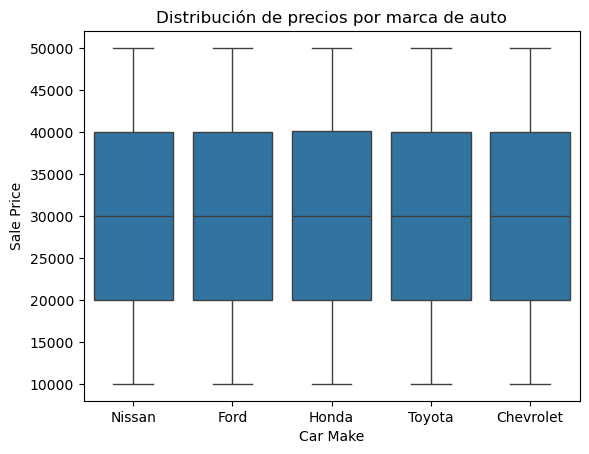

In [8]:
sns.boxplot(x="Car Make", y="Sale Price", data=df)
plt.title("Distribución de precios por marca de auto")
plt.show()

In [9]:
q_low = df["Sale Price"].quantile(0.01)
q_high = df["Sale Price"].quantile(0.99)
df = df[(df["Sale Price"] >= q_low) & (df["Sale Price"] <= q_high)]

In [10]:
print("Tamaño del dataset limpio:", df.shape)

Tamaño del dataset limpio: (2450020, 9)


In [11]:
print("\nEstadísticos descriptivos de variables numéricas:")
print(df[["Sale Price", "Commission Earned"]].describe())


Estadísticos descriptivos de variables numéricas:
         Sale Price  Commission Earned
count  2.450020e+06       2.450020e+06
mean   3.001241e+04       3.000962e+03
std    1.131423e+04       1.461948e+03
min    1.040200e+04       5.211700e+02
25%    2.022000e+04       1.839740e+03
50%    3.000600e+04       2.743840e+03
75%    3.982300e+04       3.965440e+03
max    4.959700e+04       7.437190e+03


In [12]:
print("\nFrecuencia de los modelos más comunes:")
print(df["Car Model"].value_counts().head(10))

print("\nFrecuencia de las marcas más comunes:")
print(df["Car Make"].value_counts())


Frecuencia de los modelos más comunes:
Car Model
Silverado    490792
Civic        490652
Corolla      490045
F-150        489547
Altima       488984
Name: count, dtype: int64

Frecuencia de las marcas más comunes:
Car Make
Honda        490682
Chevrolet    490510
Toyota       490149
Ford         489767
Nissan       488912
Name: count, dtype: int64


In [13]:
print("\nRango de precios:")
print("Mínimo:", df["Sale Price"].min())
print("Máximo:", df["Sale Price"].max())

print("\nRango de anios vendidos:")
print("Mínimo:", df["Car Year"].min())
print("Máximo:", df["Car Year"].max())


Rango de precios:
Mínimo: 10402
Máximo: 49597

Rango de anios vendidos:
Mínimo: 2010
Máximo: 2022


In [14]:
Q1 = df["Sale Price"].quantile(0.25)
Q3 = df["Sale Price"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Sale Price"] < Q1 - 1.5*IQR) | (df["Sale Price"] > Q3 + 1.5*IQR)]
print("\nCantidad de outliers en Precio:", outliers.shape[0])


Cantidad de outliers en Precio: 0


Descripcion de las variables y datos:
-Identifica cuales son numericas y cuales son categoricas
-Estadistico descriptivo para variables numericas
-Estadistico descriptivo para variables categoricas

In [15]:
print("Tipos de variables en el DataFrame:")
print(df.dtypes)

Tipos de variables en el DataFrame:
Date                  object
Salesperson           object
Customer Name         object
Car Make              object
Car Model             object
Car Year               int64
Sale Price             int64
Commission Rate      float64
Commission Earned    float64
dtype: object


3. Visualizaciones: Realizar gráficos que ayuden a comprender tendencias, relaciones,
diferencias, agrupamientos y otros comportamientos presentes en los datos.

In [16]:
#Estadisticos descriptivos, solo para variables numericas
pd.set_option("display.float_format", "{:,.2f}".format) #fuerza a mostrar los numeros con 2 decimales
print("\nEstadisticos descriptivos de variables numericas:")
print(df.describe())


Estadisticos descriptivos de variables numericas:
          Car Year   Sale Price  Commission Rate  Commission Earned
count 2,450,020.00 2,450,020.00     2,450,020.00       2,450,020.00
mean      2,016.00    30,012.41             0.10           3,000.96
std           3.74    11,314.23             0.03           1,461.95
min       2,010.00    10,402.00             0.05             521.17
25%       2,013.00    20,220.00             0.07           1,839.74
50%       2,016.00    30,006.00             0.10           2,743.84
75%       2,019.00    39,823.00             0.13           3,965.44
max       2,022.00    49,597.00             0.15           7,437.19


In [17]:
#Estadisticos descriptivos para variables categoricas
print("\nEstadisticos descriptivos de variables categoricas:")
print(df.describe(include=['object', 'category']))


Estadisticos descriptivos de variables categoricas:
              Date    Salesperson  Customer Name Car Make  Car Model
count      2450020        2450020        2450020  2450020    2450020
unique         366         513888         513566        5          5
top     2022-12-24  Michael Smith  Michael Smith    Honda  Silverado
freq          7006           1200           1145   490682     490792


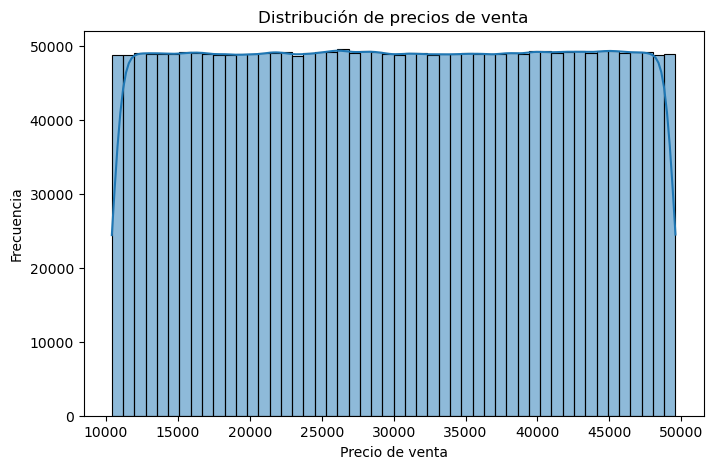

In [18]:
#Distribución de precios
plt.figure(figsize=(8,5))
sns.histplot(df["Sale Price"], bins=50, kde=True)
plt.title("Distribución de precios de venta")
plt.xlabel("Precio de venta")
plt.ylabel("Frecuencia")
plt.show()

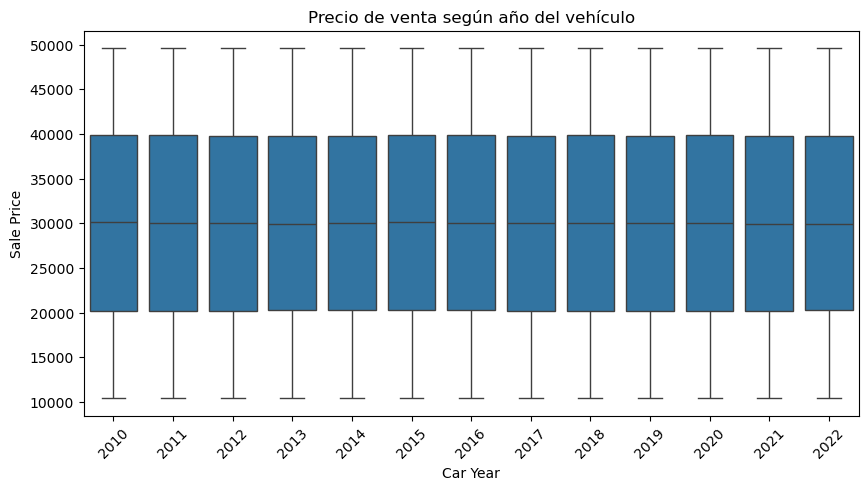

In [19]:
#Boxplot de precio por año
plt.figure(figsize=(10,5))
sns.boxplot(x="Car Year", y="Sale Price", data=df)
plt.title("Precio de venta según año del vehículo")
plt.xticks(rotation=45)
plt.show()

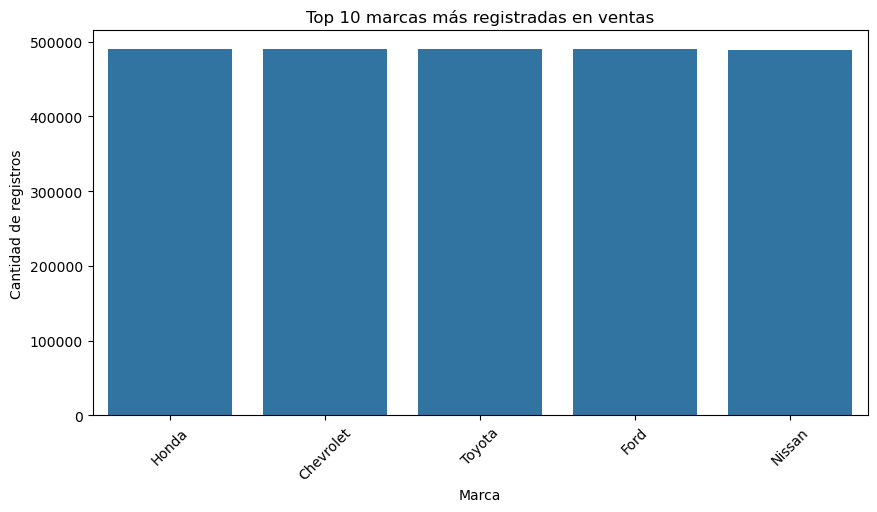

In [20]:
#Top 10 marcas más vendidas
top_makes = df["Car Make"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_makes.index, y=top_makes.values)
plt.title("Top 10 marcas más registradas en ventas")
plt.xlabel("Marca")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.show()

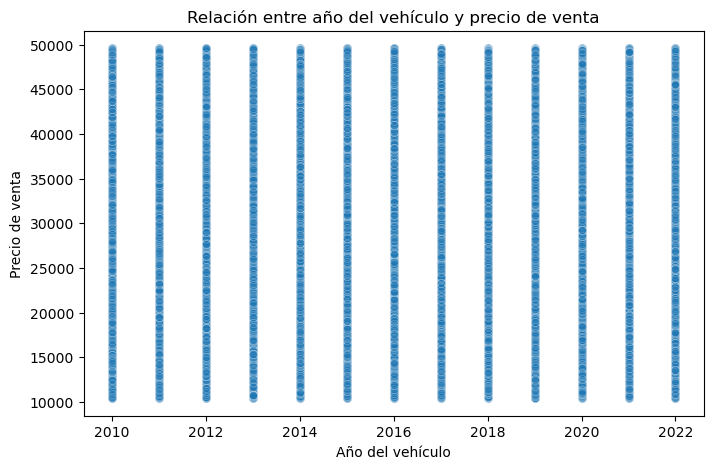

In [21]:
#Relación entre precio y año
plt.figure(figsize=(8,5))
sns.scatterplot(x="Car Year", y="Sale Price", data=df, alpha=0.3)
plt.title("Relación entre año del vehículo y precio de venta")
plt.xlabel("Año del vehículo")
plt.ylabel("Precio de venta")
plt.show()

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Silverado'),
  Text(1, 0, 'Civic'),
  Text(2, 0, 'Corolla'),
  Text(3, 0, 'F-150'),
  Text(4, 0, 'Altima')])

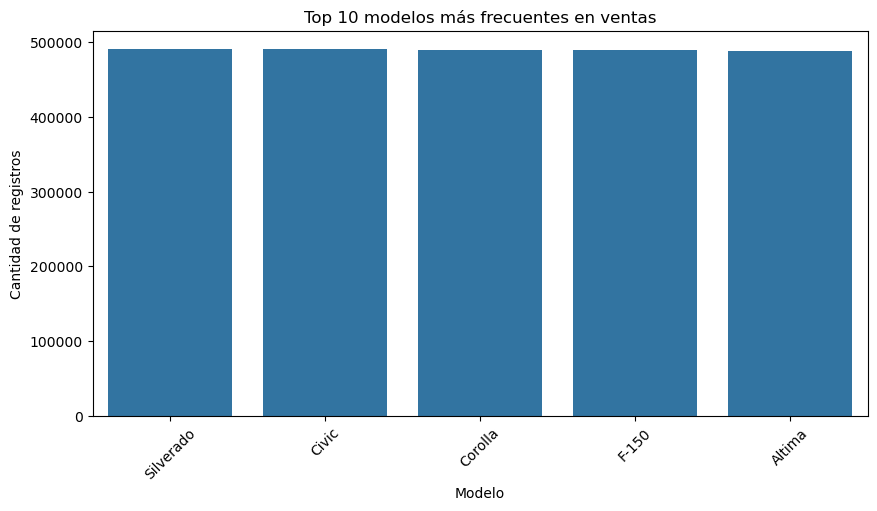

In [22]:
#Modelos más frecuentes
top_models = df["Car Model"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_models.index, y=top_models.values)
plt.title("Top 10 modelos más frecuentes en ventas")
plt.xlabel("Modelo")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)

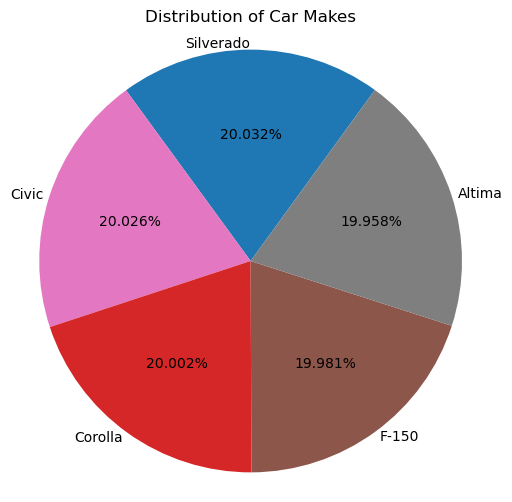

In [23]:
#Get value counts for car makes
car_model_counts = df['Car Model'].value_counts()
slices = [62, 39, 39, 38, 37, 21, 15,  9,  6,  7,  6,  5,  4, 3]
cmap = plt.cm.prism
colors = cmap(np.linspace(0., 1., len(slices)))
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(car_model_counts, labels=car_model_counts.index, labeldistance=1.03, autopct='%1.3f%%', startangle=54, colors=['C0', 'C6', 'C3', 'C5', 'C7'])
ax.axis('equal')
ax.set_title('Distribution of Car Makes')

plt.show()

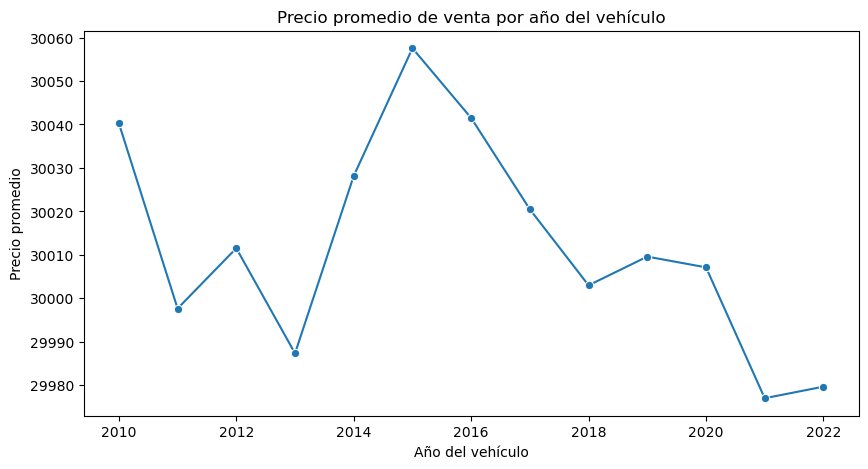

In [24]:
avg_prices = df.groupby("Car Year")["Sale Price"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=avg_prices.index, y=avg_prices.values, marker="o")
plt.title("Precio promedio de venta por año del vehículo")
plt.xlabel("Año del vehículo")
plt.ylabel("Precio promedio")
plt.show()

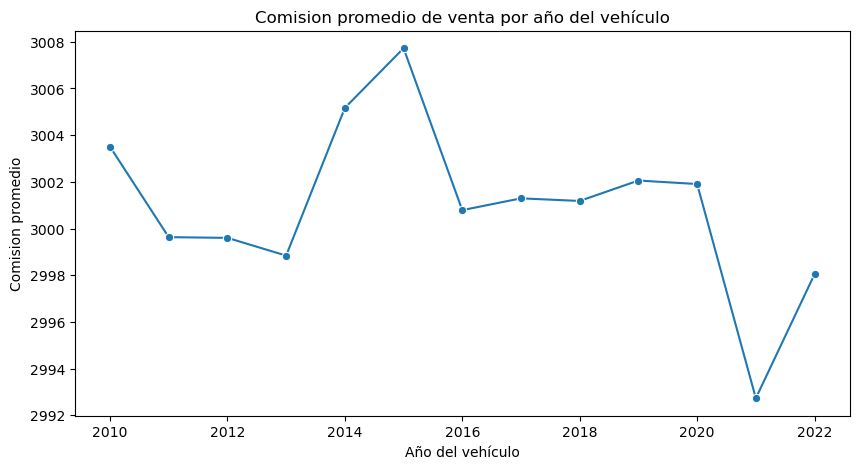

In [25]:
avg_comission = df.groupby("Car Year")["Commission Earned"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=avg_comission.index, y=avg_comission.values, marker="o")
plt.title("Comision promedio de venta por año del vehículo")
plt.xlabel("Año del vehículo")
plt.ylabel("Comision promedio")
plt.show()

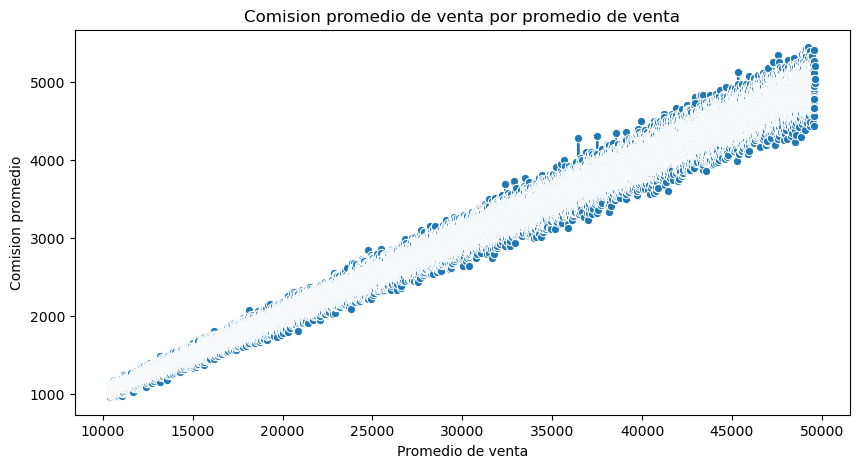

In [26]:

avg_comission = df.groupby("Sale Price")["Commission Earned"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=avg_comission.index, y=avg_comission.values, marker="o")
plt.title("Comision promedio de venta por promedio de venta")
plt.xlabel("Promedio de venta")
plt.ylabel("Comision promedio")
plt.show()

4.Observar con lupa: Realizarse las siguientes preguntas ¿qué patrones saltan a la vista?
¿qué cosas no esperabas? ¿hay alguna relación interesante? La profundidad del análisis es muy importante para ser capaces de plantear 
una buena pregunta o hipótesis de investigación.
    

Al analizar las variables Sale Price y Commission Earned, se observa un patrón claro: las comisiones tienden a aumentar a medida que lo hace el precio de venta de los vehículos. Este comportamiento es esperado, ya que las comisiones suelen calcularse como un porcentaje del valor de la transacción. Sin embargo, se encontraron casos particulares de autos con precios elevados y comisiones relativamente bajas, lo cual resulta inesperado y sugiere la influencia de la tasa de comisión aplicada en cada venta.

2.4 Teniendo ambos graficos, podemos plantear la siguiente hipotesis: 
Que el promedio de venta tiene relacion a la comision promedio.

A partir del análisis realizado, podemos concluir que existe una relación directa entre el precio de venta de los vehículos y la comisión promedio obtenida. Esto significa que, en general, a mayor valor de venta, mayor es la comisión asociada, lo cual tiene sentido dado que las comisiones suelen calcularse como un porcentaje del precio del auto. Si bien se detectaron algunos casos particulares donde esta relación no se cumple del todo, la tendencia general confirma nuestra hipótesis: el promedio de venta está positivamente relacionado con la comisión promedio.

# Simulacion e Inferencia Laboratorio 2.
Como se nos fue mencionado en la entrega numero 1 cambiamos nuestra hipotesis inicial por la siguiente:
*Los autos con año de fabricacion depues del 2019 tienen precio promedio de venta mayor que los fabricados antes del 2019*
Con esta nueva hipotesis como base procederemos con el desarrollo de este laboratorio.

# 1) Estimacion Puntual:
En nuestro caso los dos parametros fundamentales que debemos tomar en cuenta para poder seguir desarrollando nuestra hipotesis son por un lado el **año de fabricacion de los autos** para poder asi de esta manera hacer la division entre los autos con año de fabricacion previo al 2019 y los poteriores, y tambien el **precio de los autos**.
Con estos dos parametros poblacionales buscaremos hacer una comparativa entre las medias de los precios de venta de ambos grupos de estudio, esto con el fin de hacer un primer acercamiento a la diferencia que existe en los precios de ventas entre estos dos grupos.

In [27]:
df['Grupo'] = np.where(df['Car Year'] > 2019, 'Nuevo', 'Antiguo')

En primera instancia hacemos la separacion entre los autos con año de fabricacion antes y despues del 2019, esto lo logramos agregando una columna extra al dataset la cual contiene valores de *Nuevo* o *Antiguo* para asi poder diferenciar entre los distintos años y seguir con el analisis.

In [42]:
resumen = df.groupby('Grupo')['Sale Price'].agg(['count', 'mean','median','std','skew'])
print(resumen)

           count      mean    median       std  skew
Grupo                                               
Antiguo  1886122 30,019.71 30,020.00 11,313.40 -0.00
Nuevo     563898 29,987.98 29,961.00 11,316.98  0.00


Gracias a los valores obtenidos podemos ver que en promedio el precio de ventas es mayor para autos fabricados previo a 2019 que los fabricados en fechas posteriores al 2019 con una diferencia de $\$31.73$.
Tambien podemos notar que la mediana es muy similar para ambos grupos lo cual indicaria que tenemos en frente una distribucion simetrica y sin sesgo fuerte, observacion la cual podemos confirmar gracias al valor obtenido en el apartado de *skew*.
Por otro lado vemos que la desviacion estandar para ambos grupos es aproximadamente $11300$ y como la media de ambos valores rondan los $30000$ es claro mencionar que ambos grupos tienen una variabilidad similar. Esta similaridad entre las desviaciones sugiere que las diferencias en la media podrian deberse mas a un factor de azar que a una variabilidad real de los datos.
Por ultimo podemos notar que la diferencia promedio entre los precios de los autos fabricados antes del 2019 y los fabricados despues de este año es muy pequeña en comparacion a los valores de cada auto por lo que a priori no estaria demostrando ninguna variabilidad sustancial en los precios presentes en cada grupo.
Esta informacion sera vista mas a fonde en el siguiente apartado de este laboratorio gracias a la utilizacion de la tecnica de remuestreo conocida como **Bootstrap**.

# 2) Metodos de remuestreo: Bootstrap.
## ¿Que es el *Bootstrap*?
Es un metodo propuesto por *Bradley Efron* en el año 1979, el cual en escencia es un metodo computacional para estimar errores estándar e intervalos de confianza.
Este metodo nos permite aproximar la distribucion muestral de un estadistico mediante remuestreo con reemplazo de los datos originales, evitando de esta forma supuestos distribucionales fuertes y utilizando la potencia de calculo en lugar de el estudio del comportamiento de distribuciones a medida que un parametro se acerca a un limite los cuales podrian ser $0$ o $\infty$.
## ¿Como implementar *Bootstrap*?
Para poder implementar esta tecnica de remuestreo es necesario seguir una serie de pasos los cuales son bastante concretos.
Primero debemos crear un "*nuevo dataset*" el cual contendra nuestra nueva seleccion de valores provenientes de nuestro dataset original.
Estos valores son seleccionados de manera aleatoria hasta que nuestro dataset de bootstrap contenga la misma cantidad de valores que el original, cabe mencionar que los valores seleccionados pueden repetirse, a esta tecnica de seleccion de datos se le conoce como **muestreo con reemplazo**.
Luego sobre este dataset de bootstrap calculamos alguna estadistica de interes la cual podria ser la media, la mediana, entre otras. Los valores de estas estadisticas obtenidos se van almacenando en un histograma para poder llevar un registro de estos.
Por ultimo repetimos la creacion del dataset de bootstrap y el calculo de la estadistica de nuestro interes hasta tener un histograma lo suficientemente robusto para poder sacar conclusiones dependiendo de la estadistica seleccionada.
Este proceso de crear un dataset de bootstrap y calcular sobre el una medida de conoce como **bootstrapping**.
Por lo general el bootstraping y el almacenamiento de datos se repite unas $1000$ veces para poder asegurar lo robustez de nuestro histograma.

# Implementacion de *Bootstrap* a nuestro dataset.

In [29]:
listaAntiguos = df[df['Car Year'] <= 2019]['Sale Price'].tolist()
listaNuevos = df[df['Car Year'] > 2019]['Sale Price'].tolist()

Primero creamos listas para los precios de cada grupo de estudio para poder trabajar en la logica de eleccion de datos al azar.

In [43]:
bootstrap = []
mediasAntiguos = []
mediasNuevos = []
for i in range(1000):
    bootstrapAntiguo = [rand.choice(listaAntiguos) for _ in range(len(listaAntiguos))]
    bootstrapNuevo = [rand.choice(listaNuevos) for _ in range(len(listaNuevos))]
    newMediaAntiguo = np.mean(bootstrapAntiguo)
    mediasAntiguos.append(newMediaAntiguo)
    newMediaNuevo = np.mean(bootstrapNuevo)
    mediasNuevos.append(newMediaNuevo)
    bootstrap.append(newMediaAntiguo - newMediaNuevo)

Luego sobre estas listas aplicamos **bootstrapping** $1000$ veces mientras almacenamos el valor del a diferencia entre las medias de cada grupo de estudio.
Luego de aplicar la tecnica de remuestreo procedemos a la confeccion de histograma y calculo de medidas relevantes para nuestro analisis.

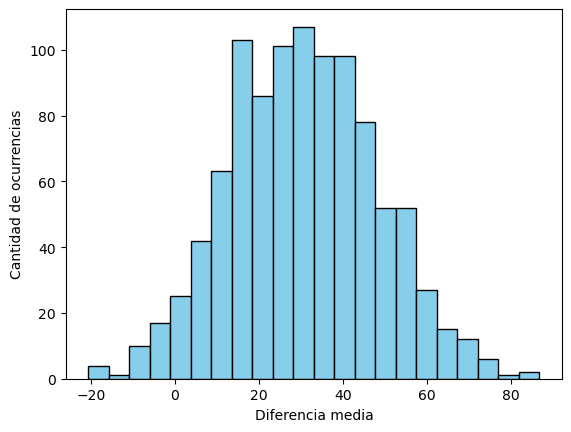

In [64]:
plt.hist(bootstrap, bins='auto', color='skyblue', edgecolor='black')
#plt.title('Diferencia de Medias')
plt.xlabel('Diferencia media')
plt.ylabel('Cantidad de ocurrencias')
plt.show()

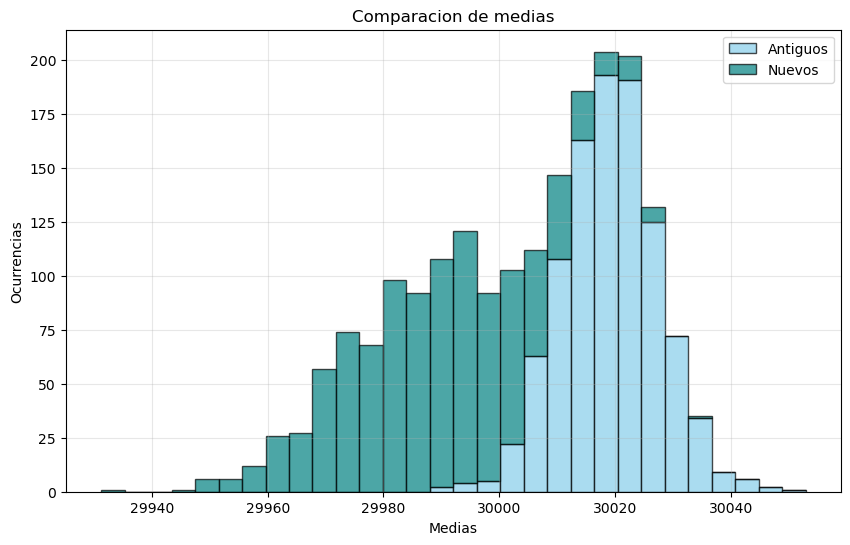

In [59]:
plt.figure(figsize=(10, 6))
plt.hist([mediasAntiguos, mediasNuevos], bins=30, label=['Antiguos', 'Nuevos'], 
         color=['skyblue', 'teal'], edgecolor=['black', 'black'], alpha=0.7, stacked=True)
plt.xlabel('Medias')
plt.ylabel('Ocurrencias')
plt.title('Comparacion de medias')
##plt.ylim(50000, 90000)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

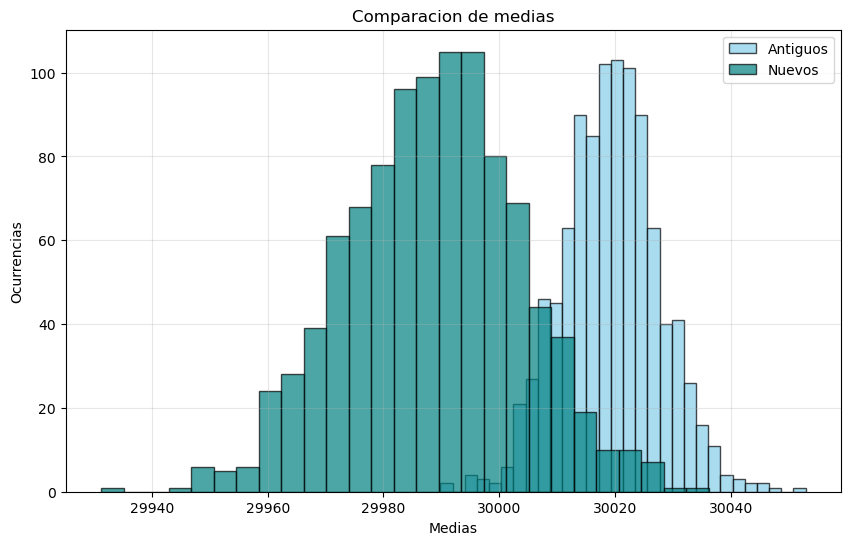

In [60]:
plt.figure(figsize=(10, 6))
plt.hist(mediasAntiguos, bins='auto', alpha=0.7, label='Antiguos', color='skyblue', edgecolor='black')
plt.hist(mediasNuevos, bins='auto', alpha=0.7, label='Nuevos', color='teal', edgecolor='black')
plt.xlabel('Medias')
plt.ylabel('Ocurrencias')
plt.title('Comparacion de medias')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [81]:
valorEstimadoAntiguo = np.mean(mediasAntiguos)
valorEstimadoAntiguoOr = np.mean(listaAntiguos)
sesgo = valorEstimadoAntiguo - valorEstimadoAntiguoOr
desviacion = np.std(mediasAntiguos)
ic95 = np.percentile(mediasAntiguos, [2.5, 97.5])
print("Antiguo:\nMedia Original = ", round(valorEstimadoAntiguoOr, 2), "\nMedia Bootstrap = ", round(valorEstimadoAntiguo, 2))
print("Sesgo = ", round(sesgo, 2))
print("Desviacion Estandar = ", round(desviacion, 2))
print("IC95% = ", ic95)

Antiguo:
Media Original =  30019.71 
Media Bootstrap =  30019.23
Sesgo =  -0.48
Desviacion Estandar =  8.42
IC95% =  [30003.46287763 30035.61682361]


In [84]:
valorEstimadoNuevo = np.mean(mediasNuevos)
valorEstimadoNuevoOr = np.mean(listaNuevos)
sesgo = valorEstimadoNuevo - valorEstimadoNuevoOr
desviacion = np.std(mediasNuevos)
ic95 = np.percentile(mediasNuevos, [2.5, 97.5])
print("Antiguo:\nMedia Original = ", round(valorEstimadoNuevoOr, 2), "\nMedia Bootstrap = ", round(valorEstimadoNuevo, 2))
print("Sesgo = ", round(sesgo, 2))
print("Desviacion Estandar = ", round(desviacion, 2))
print("IC95% = ", ic95)

Antiguo:
Media Original =  29987.98 
Media Bootstrap =  29988.58
Sesgo =  0.6
Desviacion Estandar =  14.97
IC95% =  [29959.37354655 30017.98269461]


Mediante la técnica de remuestreo bootstrap, se estimaron los parámetros poblacionales de la media de precios de venta para los autos fabricados previo al año $2019$ y posterior a este.
Los resultados muestran que los valores bootstrap coinciden estrechamente con las medias originales y presentan un sesgo muy cercano a $0$ por lo que los podemos despreciar.
Además, el grupo de autos frabricados previo al $2019$ presenta un menor error estándar y un intervalo de confianza más acotado, indicando mayor estabilidad en sus resultados.

Con la informacion obtenida gracias a este metodo de remuestreo podemos ver que la tendencia es que los autos con años de fabricacion mas antiguos cuentan con un valor de venta promedio mayor que los autos mas nuevos.

# Respondiendo Preguntas Planteadas.
## ¿Existen diferencias relevantes entre el analisis realizado con el dataset original y el realizado utilizando bootstrap?
**R:** Podemos notar que al comparar los datos obtenidos en ambos estudios (*original y bootstrap*) que no hay una diferencia sustancial entre ellos, lo que nos indica que el primer analisis realizado con nuestro dataset original es estable y por sobre todo representativo, ya que a pesar de hacer un remuestreo de los datos, las estadisticas estudiadas no varian practicamente nada, por lo que nuestra estimacion inicial representa de manera fiel a la poblacion.
## ¿Que ventajas aporta el uso de bootstrap a nuestro analisis y que limitaciones salen a la luz?
**R:** La ventaja que nos aporta el metodo de bootstrap a nuestro analisis es la posibilidad de corroborar o refutar ideas planteadas en base a nuestro dataset original ya que estos nos permite determinar su nuestro analisis esta bien encaminado o si hay elementos que hemos pasado por alto y deberiamos tomar en cuenta y una de las limitaciones mas grande que pudimos notar es el costo computacional que representa el uso de esta tecnica sobre nuestro dataset ya que este al ser muy grande contando con $2450020$ filas, al momento de realizar un remuestreo $1000$ veces y ademas hacer calculos sobre este mismo los tiempos de ejecucion se exedian demasiado.

In [87]:
print("Tamaño dataset: ", len(df))

Tamaño dataset:  2450020
